In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import os, sys
from astropy.io import fits
import healpy as hp

from scipy.interpolate import interp1d
from scipy.optimize import minimize, shgo
from scipy.stats import poisson
from scipy import signal

sys.path.append('..')

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../notebooks/matplotlibrc')

## 0. Common

In [2]:
ebins = 2*np.logspace(-1, 3, 41)
# de = ebins[1:] - ebins[:-1]
# emid = 10**((np.log10(ebins[1:]) + np.log10(ebins[:-1]))/2.)
print([f'{ebin:.1f}' for ebin in ebins[10:20]])

['2.0', '2.5', '3.2', '4.0', '5.0', '6.3', '8.0', '10.0', '12.6', '15.9']


In [3]:
# for counts: central pixel is indexed central_pix_ind=899.5 (900.5th), center value is 0.
# 900th (index 899) from -0.1 to 0, 901th (index 900) from 0 to 0.1
# for exposure: central pixel is indexed central_pix_ind=1799.5 (1800.5th), center value is 0.
# 900th (index 899) from -0.1 to 0, 901th (index 900) from 0 to 0.1
def deg2ipix(deg, pixel_size_data, central_pix_ind, side='left'):
    if side == 'left':
        deg_center = deg + pixel_size_data/2
    elif side == 'right':
        deg_center = deg - pixel_size_data/2
        
    ipix = deg_center / pixel_size_data + central_pix_ind
    if not ipix % 1 == 0:
        raise ValueError('non integer index')
    return int(ipix)

def downsample(arr, f):
    """Converts a shape (h, w) array into a (h//f, w//f) array
    by adding the values in f*f blocks."""
    h, w = arr.shape
    if h%f != 0 or w%f != 0:
        raise ValueError('h and w need to be multiples of f')
    return np.sum([[arr[i::f, j::f] for j in range(f)] for i in range(f)], axis=(0,1))

## 1. Counts from '/zfs/tslatyer/fermidata/exposure/pass8_573weeks'

In [4]:
counts_fits = fits.open(f'data/ccube_ultracleanveto_bestpsf_halfsky1.fits')

pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 20
i_e_st = np.searchsorted(counts_fits[1].data['E_MIN'], 2e6) # 2 GeV = 2e6 keV
i_e_ed = np.searchsorted(counts_fits[1].data['E_MIN'], 2e7)
print(f'ebin [{i_e_st}:{i_e_ed}]')

counts = np.sum(counts_fits[0].data[i_e_st:i_e_ed], axis=0)

ebin [10:20]


In [5]:
ipix_st = deg2ipix(-extent, pixel_size_data, 899.5, side='left')
ipix_ed = deg2ipix( extent, pixel_size_data, 899.5, side='right') # inclusive
print(f'ipix [{ipix_st}:{ipix_ed}+1]')
counts = counts[ipix_st:ipix_ed+1, ipix_st:ipix_ed+1]

downsample_factor = int(pixel_size_target / pixel_size_data)

counts_downsampled = downsample(counts, downsample_factor)

ipix [700:1099+1]


In [6]:
np.save('data/counts_573week.npy', counts_downsampled)

/tmp/ipykernel_240022/2423289026.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(counts_downsampled))


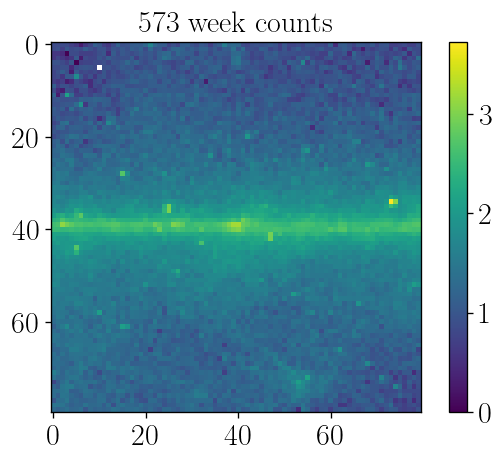

In [39]:
plt.imshow(np.log10(counts_downsampled))
plt.title('573 week counts')
plt.colorbar()

In [36]:
z = to_cart(np.load('data/fermidata_counts_512.npy'), n_pixels=100, pixelsize=0.5, offset=(0.5, -0.5))

In [42]:
zhp = np.load('data/fermidata_counts_512.npy')
np.min(zhp[zhp>0])

1.0

/tmp/ipykernel_240022/3496529208.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(z))


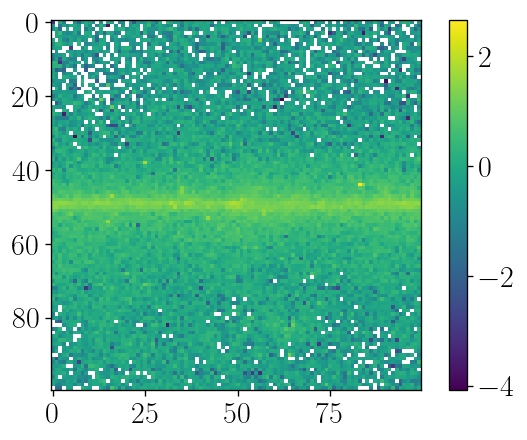

In [38]:
plt.imshow(np.log10(z))
plt.colorbar()

## 2. Exposure

In [32]:
exposure_fits = fits.open(f'data/exposure-ultracleanveto-bestpsf.fits')

pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 25
i_e_st = np.searchsorted(exposure_fits[1].data['ENERGY'], 2e3) # 2 GeV = 2e3 MeV
i_e_ed = np.searchsorted(exposure_fits[1].data['ENERGY'], 2e4) # 20 GeV
print(f'ebin [{i_e_st}:{i_e_ed}]')

exposure = exposure_fits[0].data[i_e_st:i_e_ed]

ebin [10:20]


In [33]:
ipix_st = deg2ipix(-extent, pixel_size_data, 1799.5, side='left')
ipix_ed = deg2ipix( extent, pixel_size_data, 1799.5, side='right') # inclusive
print(f'ipix [{ipix_st}:{ipix_ed}+1]')
exposure = exposure[:, ipix_st:ipix_ed+1, ipix_st:ipix_ed+1]

downsample_factor = int(pixel_size_target / pixel_size_data)

exposure_downsampled = np.array([downsample(exp, downsample_factor) for exp in exposure])

ipix [1550:2049+1]


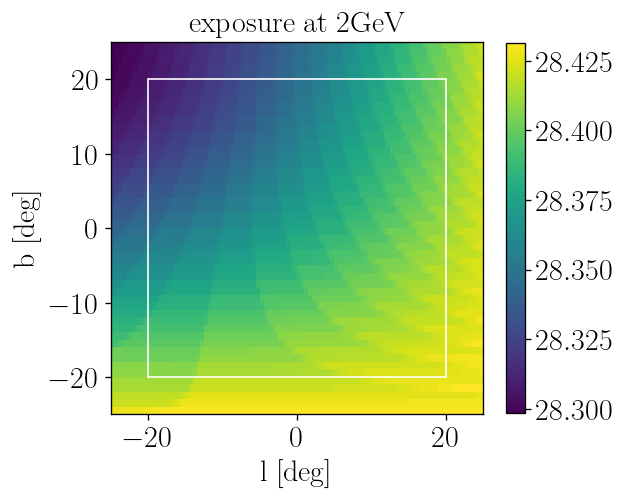

In [34]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(np.log(np.fliplr(exposure_downsampled[0])), extent=(-extent, extent, -extent, extent))
ax.add_patch(mpl.patches.Rectangle((-20,-20), 40, 40, fc=(0,0,0,0), ec='w'))
ax.set(title='exposure at 2GeV', xlabel='l [deg]', ylabel='b [deg]')
fig.colorbar(im, shrink=0.8)

In [16]:
from utils.cart import to_cart

In [26]:
exp = to_cart(np.load('data/fermidata_exposure_512.npy'), n_pixels=100, pixelsize=0.5, offset=(0.5, -0.5))

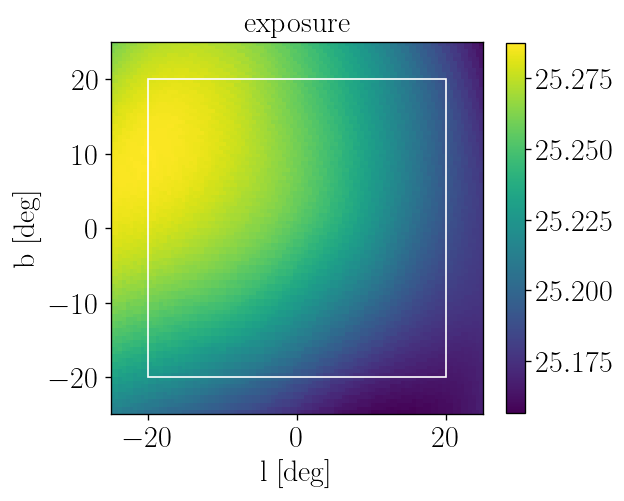

In [27]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(np.log(np.fliplr(exp)), extent=(-extent, extent, -extent, extent))
ax.add_patch(mpl.patches.Rectangle((-20,-20), 40, 40, fc=(0,0,0,0), ec='w'))
ax.set(title='exposure', xlabel='l [deg]', ylabel='b [deg]')
fig.colorbar(im, shrink=0.8)

## 2. Diffuse templates

In [8]:
TMPL_DIR = '/zfs/tslatyer/fermimaps/allsky/PASS8_Jun19_UltracleanVeto/specbin'

In [9]:
for diff_name in ['p6v11', 'ccwaics', 'ccwapibrem', 'ccwfics', 'ccwfpibrem']:
    
    print(diff_name)

    nsideload = 512
    npixload = hp.nside2npix(nsideload)
    pixarea = hp.nside2pixarea(nsideload)

    # Setup energy bins
    ebins_str = ['0002.0','0002.5', '0003.2','0004.0','0005.0',
                 '0006.3','0008.0','0010.0','0012.6','0015.9','0020.0']
    ebins = 2*np.logspace(-1, 3, 41)
    de = ebins[1:] - ebins[:-1]
    emid = 10**((np.log10(ebins[1:]) + np.log10(ebins[:-1]))/2.)

    # Get the correct bins
    de = de[10:20]
    emid = emid[10:20]

    # init
    diff = np.zeros(npixload)

    diffload = fits.open(f'{TMPL_DIR}/diffuse_model_map_healpix_{diff_name}_PASS8_Jun19_UltracleanVeto_bestpsf.fits')
    diffall = diffload[0].data

    for i in range(10):
        # Diff has all 40, 2 GeV is i=10, so start there
        # NB!!! The diffuse model has different units to everything else.
        # It is already exposure corrected, but is divided by the bin size in MeV
        # I'm here copying the approach in the fermi plugin
        diff += diffall[:, i+10] * de[i] * 4.*np.pi/npixload * 1e3

    # Change nside to output value
    nside = nsideload
    npix = hp.nside2npix(nside)
    diff = hp.ud_grade(diff, nside, power=-2)

    # Adjust templates to all have mean 1 in the ROI
    # ROI: |b| >= 2, |r| <= 30
    theta, phi = hp.pix2ang(nside, range(npix))
    larr = np.zeros(npix)
    for i in range(npix):
        #larr[i] = pm.mod(phi[i]+np.pi,2*np.pi)-np.pi
        larr[i] = ((phi[i]+np.pi) % (2*np.pi)) - np.pi
    barr = np.pi/2 - theta
    rarr = np.arccos(np.cos(larr)*np.cos(barr))

    roi = np.where((np.abs(barr) >= 2*np.pi/180.) & (rarr <= 30*np.pi/180.))[0]

    diff /= np.mean(diff[roi])

    np.save(f'data/template_{diff_name}_512.npy', diff)

p6v11
ccwaics
ccwapibrem
ccwfics
ccwfpibrem


## 3. Other templates

In [10]:
# get filenames and eng labels
fns = [fn for fn in os.listdir(TMPL_DIR) if 'fwhm000-0512-bestpsf-nopsc' in fn]
eng_str_s = [fn.split('GeV')[0].split('-')[-1] for fn in fns]
eng_eng_str_s = [(float(eng_str), eng_str) for eng_str in eng_str_s]
eng_eng_str_s.sort()

eng_lstr_s = [fn.split('GeV')[0].split('-')[-2] for fn in fns]
eng_eng_lstr_s = [(float(eng_str), eng_str) for eng_str in eng_lstr_s]
eng_eng_lstr_s.sort()

eng_eng_str_s.insert(0, eng_eng_lstr_s[0])
#print(eng_eng_str_s)

In [11]:
# First load data and exposure
# 0 entry in units of [counts/cm^2/s/sr]
# exposure in [cm^2 s]

nsideload = 512
npixload = hp.nside2npix(nsideload)
pixarea = hp.nside2pixarea(nsideload)

# Setup energy bins
ebins_str = [eng_str for eng, eng_str in eng_eng_str_s[10:21]]
ebins = 2*np.logspace(-1,3,41)
de = ebins[1:] - ebins[:-1]
emid = 10**((np.log10(ebins[1:]) + np.log10(ebins[:-1]))/2.)

# Get the correct bins
de = de[10:20]
emid = emid[10:20]

# Load maps
counts = np.zeros(npixload)
expall = np.zeros(shape=(npixload,10))
pscmdl = np.zeros(npixload)

for i in range(10):
    load = fits.open(f'{TMPL_DIR}/fermi-allsky-{ebins_str[i]}-{ebins_str[i+1]}GeV-fwhm000-0512-bestpsf-nopsc.fits')
    fi = load[0].data
    ei = load[1].data
    countsi = fi*ei*pixarea # [counts/pixel]
    counts += countsi
    expall[:,i] = ei

    load = fits.open(f'{TMPL_DIR}/fermi-allsky-{ebins_str[i]}-{ebins_str[i+1]}GeV-fwhm000-0512-bestpsf-pscmdl.fits')
    pi = load[0].data

    pscmdl += pi*ei

# Round counts to be exact, some values slightly off an integer in above
counts = np.round(counts)
exp = np.mean(expall, axis=1)

# Load ps mask
load = fits.open('/zfs/nrodd/MakeNPTFitData/PtSourceMask/Allpscmask_3FGL-energy2.00000_0.95_ULTRACLEANVETO_bestpsf.fits') 
psmask = load[0].data

# Change nside to output value
nside = 512
npix = hp.nside2npix(nside)
#counts = hp.ud_grade(counts, nside, power=-2)
#exp = hp.ud_grade(exp, nside, power=0)
#diff = hp.ud_grade(diff, nside, power=-2)
#pscmdl = hp.ud_grade(pscmdl, nside, power=-2)

# Output exposure before any further manipulations, to avoid its value getting reset
np.save('data/fermidata_exposure_512.npy', exp)

# Load the other templates - these are nside 256
iso = exp
temps = fits.open('/zfs/nrodd/Templates/template_finenfw3.fits')[1].data
bub = hp.ud_grade(temps[9][4], nside, power=-2) * exp
nfw = hp.ud_grade(temps[195][4], nside, power=-2) * exp
disk = hp.ud_grade(fits.open('/zfs/nrodd/MakeNPTFitData/raw_disk.fits')[0].data, nside, power=-2) * exp

# Adjust templates to all have mean 1 in the ROI
# ROI: |b| >= 2, |r| <= 30
theta, phi = hp.pix2ang(nside, range(npix))
larr = np.zeros(npix)
for i in range(npix):
    #larr[i] = pm.mod(phi[i]+np.pi,2*np.pi)-np.pi
    larr[i] = ((phi[i]+np.pi) % (2*np.pi)) - np.pi
barr = np.pi/2 - theta
rarr = np.arccos(np.cos(larr)*np.cos(barr))

roi = np.where((np.abs(barr) >= 2*np.pi/180.) & (rarr <= 30*np.pi/180.))[0]

#diff /= np.mean(diff[roi])
pscmdl /= np.mean(pscmdl[roi])
iso  /= np.mean(iso[roi])
bub  /= np.mean(bub[roi])
nfw  /= np.mean(nfw[roi])
disk /= np.mean(disk[roi])

np.save('data/fermidata_counts_512.npy', counts)
np.save('data/fermidata_pscmask_512.npy', psmask)
#np.save('data/template_dif_512.npy', diff)
np.save('data/template_iso_512.npy', iso)
np.save('data/template_bub_512.npy', bub)
np.save('data/template_gce_512.npy', nfw)
np.save('data/template_psc_512.npy', pscmdl)
np.save('data/template_dsk_512.npy', disk)

## A. Counts files in TMPL_DIR_573W?
fermi-allsky-[...]-[...]GeV-fwhm000-0512-bestpsf-nopsc.fits

In [ ]:
# get filenames and eng labels
fns = [fn for fn in os.listdir(DATA_DIR_573W) if 'fwhm000-0512-bestpsf-nopsc' in fn]
eng_str_s = [fn.split('GeV')[0].split('-')[-1] for fn in fns]
eng_eng_str_s = [(float(eng_str), eng_str) for eng_str in eng_str_s]
eng_eng_str_s.sort()
eng_eng_str_s.insert(0, (0.2, '000.2'))

In [ ]:
f = fits.open(f'{TMPL_DIR_573W}/{fns[0]}')

In [ ]:
f[1].header

In [ ]:
hp.mollview(np.log(f[0].data))

In [ ]:
hp.mollview(f[1].data)

In [ ]:
f[0].header

In [ ]:
hp.mollview(f[2].data)